<a href="https://colab.research.google.com/github/ps-research/I2-Hate/blob/main/Diversity_Analysis/I2_Hate_BERTopic_Analysis_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bertopic umap-learn hdbscan sentence-transformers plotly --quiet

In [ ]:
import json
import pandas as pd
import numpy as np
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
with open('/content/drive/MyDrive/EACL NEW DATA/EACL_26-HateSpeechDataset.json', 'r') as f:
    data = json.load(f)

texts = [sample['text'] for sample in data]
print(f"Loaded {len(texts)} tweets\n")

Loaded 3296 tweets



In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

nltk_stopwords = list(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
vectorizer_model = CountVectorizer(
    stop_words=nltk_stopwords,
    min_df=2,           # Ignore very rare words
    max_df=0.95,        # Ignore very common words
    ngram_range=(1, 3)  # Allow phrases (unigrams to trigrams)
)

In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [ ]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

In [ ]:
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

In [ ]:
keybert_model = KeyBERTInspired()
mmr_model = MaximalMarginalRelevance(diversity=0.3)
representation_model = {
    "KeyBERT": keybert_model,
    "MMR": mmr_model
}

In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    top_n_words=10,
    nr_topics="auto",
    verbose=True
)

In [ ]:
topics, probs = topic_model.fit_transform(texts)

2025-11-23 12:50:11,615 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

2025-11-23 12:50:25,091 - BERTopic - Embedding - Completed ✓
2025-11-23 12:50:25,095 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-23 12:51:05,234 - BERTopic - Dimensionality - Completed ✓
2025-11-23 12:51:05,236 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-23 12:51:05,411 - BERTopic - Cluster - Completed ✓
2025-11-23 12:51:05,412 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-11-23 12:51:06,947 - BERTopic - Representation - Completed ✓
2025-11-23 12:51:06,949 - BERTopic - Topic reduction - Reducing number of topics
2025-11-23 12:51:06,964 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-23 12:51:10,080 - BERTopic - Representation - Completed ✓
2025-11-23 12:51:10,082 - BERTopic - Topic reduction - Reduced number of topics from 28 to 22


In [ ]:
topic_info = topic_model.get_topic_info()
print(f"Found {len(topic_info) - 1} topics (excluding outliers)")

Found 21 topics (excluding outliers)


In [ ]:
# Show topics with better keywords
for topic_id in range(min(15, len(topic_info)-1)):
    if topic_id == -1:
        continue

    print(f"\nTOPIC {topic_id} ({topic_info[topic_info['Topic']==topic_id]['Count'].values[0]} posts)")
    print("-" * 80)

    # Get keywords from different representations
    topic_words = topic_model.get_topic(topic_id)

    print("Top keywords (KeyBERT):")
    if hasattr(topic_model, 'get_topic_representations'):
        keybert_words = topic_model.topic_representations_[topic_id]['KeyBERT'][:10]
        print(", ".join([word for word, _ in keybert_words]))
    else:
        print(", ".join([word for word, _ in topic_words[:10]]))

    print("\nTop keywords (MMR):")
    if hasattr(topic_model, 'get_topic_representations'):
        mmr_words = topic_model.topic_representations_[topic_id]['MMR'][:10]
        print(", ".join([word for word, _ in mmr_words]))

    # Show representative documents
    docs = topic_model.get_representative_docs(topic_id)[:2]
    print("\nRepresentative posts:")
    for i, doc in enumerate(docs, 1):
        print(f"  {i}. {doc[:150]}...")


TOPIC 0 (844 posts)
--------------------------------------------------------------------------------
Top keywords (KeyBERT):
soros, george, george soros, world, black, want, country, border, funded, nothing

Top keywords (MMR):

Representative posts:
  1. I feel so bad for George Soros. He's just a sweet old man trying to help the world. He's just using the fortune he definitely didn't make by breaking ...
  2. Let's follow the money, shall we? 1. A street militant from Antifa gets arrested for assault in Portland. 2. Their bail is paid by the 'National Bail ...

TOPIC 1 (413 posts)
--------------------------------------------------------------------------------
Top keywords (KeyBERT):
aipac, israel, mossad, foreign, cia, american, 11, military, zionist, treason

Top keywords (MMR):

Representative posts:
  1. For the newfags just getting redpilled on 9/11, here's a quick thread on the basics. 
1/ Forget Al-Qaeda. The real perps were the 5 'Dancing Israelis'...
  2. A source from the 

In [ ]:
def generate_topic_label(topic_id):
    """Generate descriptive label from top keywords"""
    if topic_id == -1:
        return "Outliers"

    topic_words = topic_model.get_topic(topic_id)

    # Get top 3 most representative words
    top_words = [word for word, _ in topic_words[:3]]

    # Create label
    label = " + ".join(top_words).title()
    return label

# Apply automatic labels
topic_info['Auto_Label'] = topic_info['Topic'].apply(generate_topic_label)

In [ ]:
def infer_category(keywords):
    keywords_lower = " ".join([w.lower() for w, _ in keywords])

    # Immigration
    if any(word in keywords_lower for word in ['immig', 'border', 'illegal', 'deport', 'alien', 'refugee', 'asylum']):
        return "Immigration"

    # Religion (including coded antisemitism)
    elif any(word in keywords_lower for word in [
        'jew', 'jewish', 'israel', 'zionist', 'antisem', 'muslim', 'islam', 'christian', 'religion',
        'soros', 'rothschild', 'aipac', 'mossad', 'zog', 'holohoax', 'holocaust',  # ADDED
        'synagogue', 'mosque', 'kosher', 'sharia', 'jihad'  # ADDED
    ]):
        return "Religion"

    # Race & Ethnicity
    elif any(word in keywords_lower for word in [
        'black', 'white', 'race', 'racial', 'blm', 'african', 'asian', 'chinese',
        'confederate', 'slavery', 'slave', 'kkk', 'supremac'  # ADDED
    ]):
        return "Race & Ethnicity"

    # LGBTQ+ & Gender
    elif any(word in keywords_lower for word in ['trans', 'gay', 'lgbt', 'queer', 'gender', 'pronoun', 'homosexual']):
        return "LGBTQ+ & Gender"

    # Women & Gender
    elif any(word in keywords_lower for word in ['women', 'woman', 'feminist', 'female', 'misog', 'bitch', 'slut', 'whore']):
        return "Women & Gender"

    # Politics (NEW CATEGORY)
    elif any(word in keywords_lower for word in [
        'trump', 'maga', 'democrat', 'republican', 'liberal', 'conserv', 'election', 'vote',
        'biden', 'obama', 'clinton', 'fascist', 'communist', 'socialist'
    ]):
        return "Politics"

    # Conspiracy Theories (NEW CATEGORY)
    elif any(word in keywords_lower for word in [
        'gates', 'bill gates', 'deep state', 'cabal', 'elite', 'globalist',
        'federal reserve', 'fed', 'illuminati', 'mason', 'satanic', 'pedophile'
    ]):
        return "Conspiracy Theories"

    # Health/COVID (if relevant)
    elif any(word in keywords_lower for word in ['vacc', 'covid', 'virus', 'pandemic', 'mask']):
        return "Health & COVID"

    # Native/Indigenous Issues (NEW)
    elif any(word in keywords_lower for word in ['tribal', 'reservation', 'native', 'indigenous', 'aboriginal']):
        return "Indigenous Issues"

    else:
        return "Other"

topic_info['Category'] = topic_info['Topic'].apply(
    lambda t: infer_category(topic_model.get_topic(t)) if t != -1 else "Outliers"
)

In [ ]:
topics_df = topic_info[topic_info['Topic'] != -1].copy()
topics_df['Percentage'] = (topics_df['Count'] / len(texts) * 100).round(1)
topics_df = topics_df.sort_values('Count', ascending=False)

In [ ]:
print("TOPIC SUMMARY (Top 15)")
print(topics_df[['Topic', 'Category', 'Auto_Label', 'Count', 'Percentage']].head(15).to_string(index=False))

TOPIC SUMMARY (Top 15)
 Topic            Category                             Auto_Label  Count  Percentage
     0         Immigration          Soros + George + George Soros    844        25.6
     1            Religion                Aipac + Israel + Mossad    413        12.5
     2    Race & Ethnicity                   1B + American + Tech    164         5.0
     3               Other                      Kgb + Putin + Fsb    107         3.2
     4    Race & Ethnicity            Hollywood + Disney + Zaslav    102         3.1
     5   Indigenous Issues            Land + Reservation + Tribal     98         3.0
     6            Politics                 Maga + Trump + Fascist     93         2.8
     7    Race & Ethnicity    Confederate + Confederacy + Slavery     92         2.8
     8 Conspiracy Theories              Food + Gates + Bill Gates     92         2.8
     9            Religion     Syndicate + Nostra + Kosher Nostra     89         2.7
    10            Religion                

In [ ]:
category_counts = topics_df.groupby('Category').agg({
    'Count': 'sum',
    'Topic': 'count'
}).rename(columns={'Topic': 'Num_Topics'})
category_counts['Percentage'] = (category_counts['Count'] / len(texts) * 100).round(1)
category_counts = category_counts.sort_values('Count', ascending=False)

In [ ]:
print("SOCIAL ISSUE CATEGORIES")
print(category_counts.to_string())

SOCIAL ISSUE CATEGORIES
                     Count  Num_Topics  Percentage
Category                                          
Immigration            844           1        25.6
Religion               668           4        20.3
Race & Ethnicity       358           3        10.9
Conspiracy Theories    271           4         8.2
Other                  225           3         6.8
Women & Gender         206           3         6.2
Indigenous Issues       98           1         3.0
Politics                93           1         2.8
LGBTQ+ & Gender         42           1         1.3


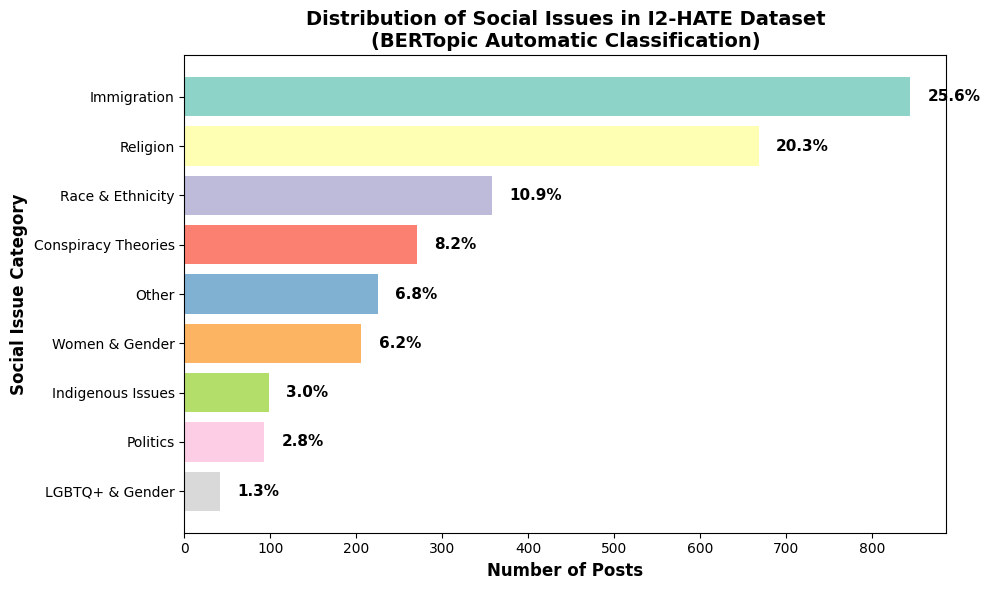

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
categories = category_counts.index.tolist()
counts = category_counts['Count'].tolist()
percentages = category_counts['Percentage'].tolist()

colors = plt.cm.Set3(range(len(categories)))
bars = ax.barh(categories, counts, color=colors)

ax.set_xlabel('Number of Posts', fontsize=12, fontweight='bold')
ax.set_ylabel('Social Issue Category', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Social Issues in I2-HATE Dataset\n(BERTopic Automatic Classification)',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add percentage labels
for i, (cat, count, pct) in enumerate(zip(categories, counts, percentages)):
    ax.text(count + 20, i, f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

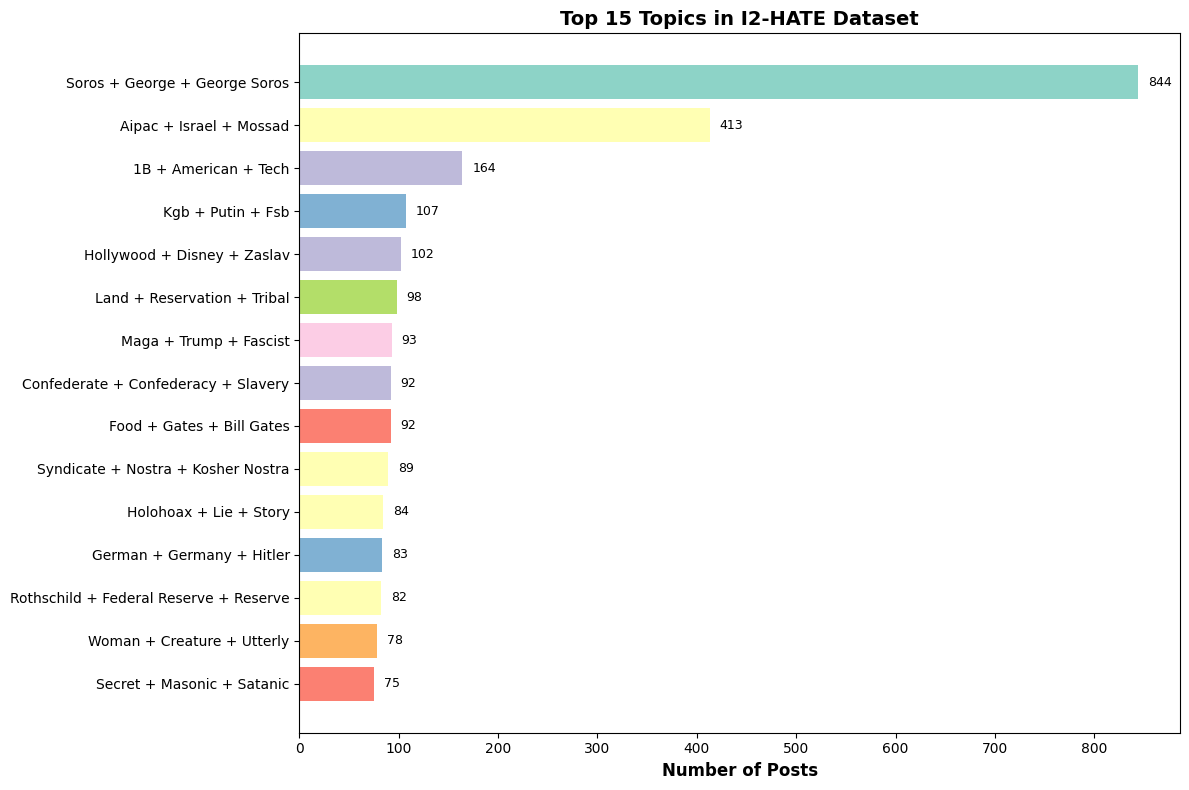

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
top15 = topics_df.head(15).copy()
labels = top15['Auto_Label'].tolist()
counts = top15['Count'].tolist()

# Color by category
category_colors = {cat: plt.cm.Set3(i) for i, cat in enumerate(category_counts.index)}
colors = [category_colors[cat] for cat in top15['Category']]

bars = ax.barh(range(len(labels)), counts, color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Number of Posts', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Topics in I2-HATE Dataset',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add counts
for i, count in enumerate(counts):
    ax.text(count + 10, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()